In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os

data_dir = 'Shoe vs Sandal vs Boot Dataset'
img_height = 128
img_width = 128
batch_size = 32
seed = 123

print(os.listdir(data_dir))

I0000 00:00:1784787123.162040    1036 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784787123.976831    1036 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784787126.722044    1036 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


['Boot', 'Sandal', 'Shoe']


labels
Boot      5000
Sandal    5000
Shoe      5000
dtype: int64
(15000, 3)


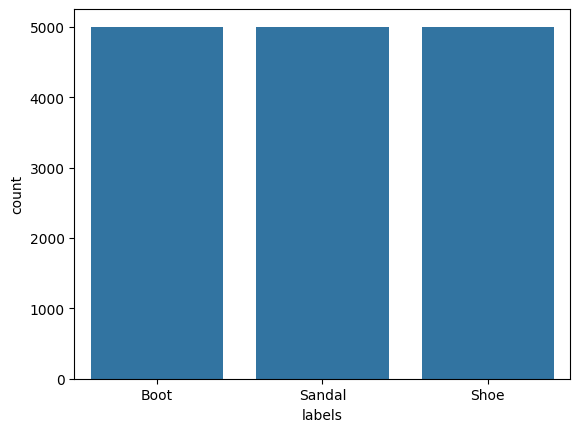

In [2]:
import pandas as pd
import seaborn as sns

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(data_dir):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

df = pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})
print(df.groupby(['labels']).size())
print(df.shape)

sns.countplot(x=df['labels'])
plt.show()

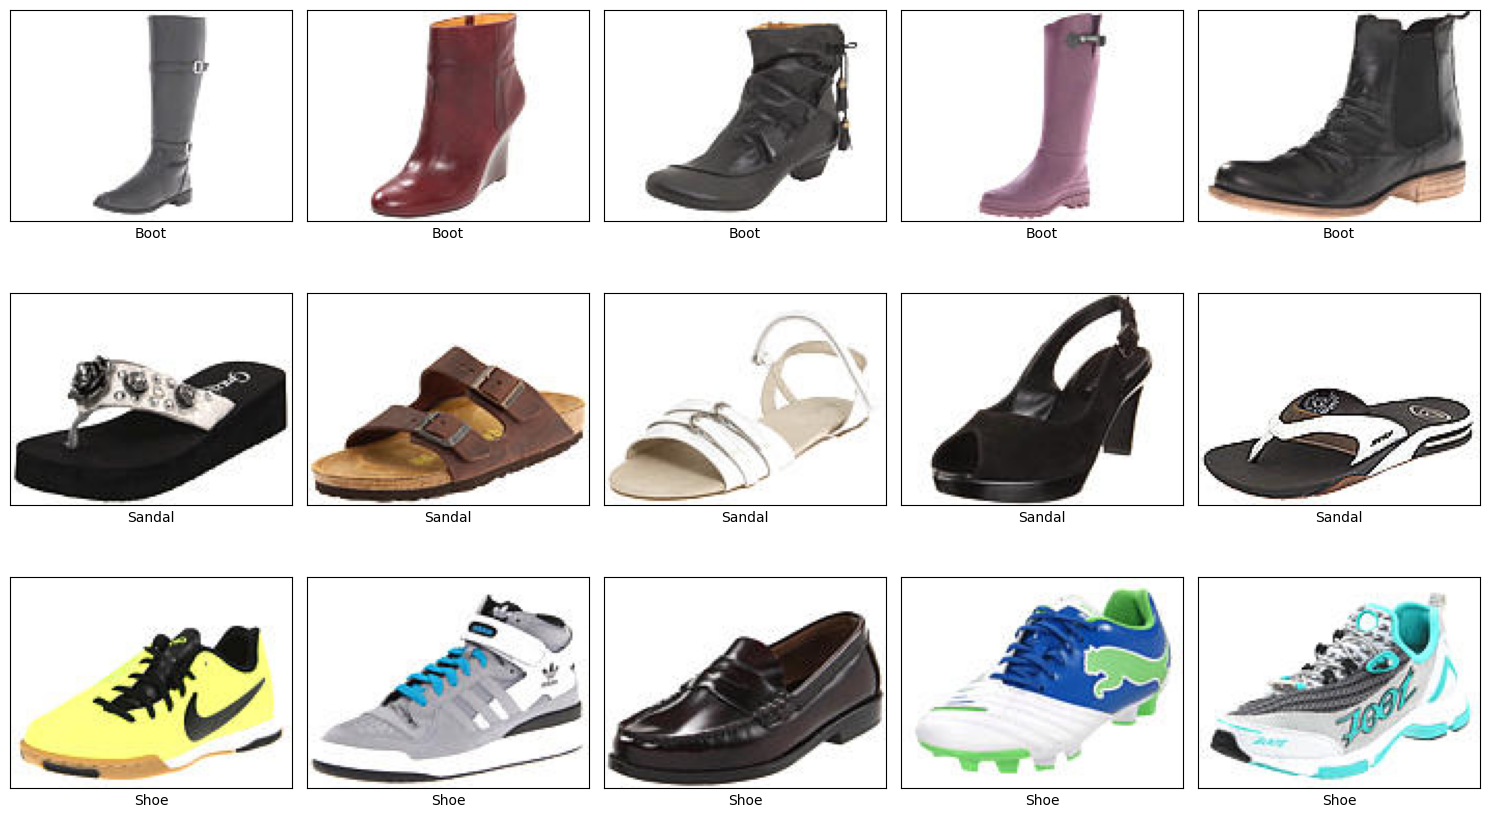

In [5]:
import random
from PIL import Image

fig, axs = plt.subplots(3, 5, figsize=(15, 9))

for i, class_name in enumerate(sorted(df['labels'].unique())):
    sample = df[df['labels'] == class_name].sample(5)
    for j, (idx, row) in enumerate(sample.iterrows()):
        img = Image.open(row['path'])
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()
plt.show()

In [6]:
sizes = set()
for p in df['path'].sample(2000, random_state=seed):
    with Image.open(p) as img:
        sizes.add(img.size)

print("Jumlah resolusi unik:", len(sizes))
print(list(sizes)[:10])

Jumlah resolusi unik: 1
[(136, 102)]


In [7]:
from sklearn.model_selection import train_test_split

X = df['path']
y = df['labels']

# Split pertama: 80% train, 20% sisanya
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed)

# Split kedua: sisa 20% dibagi dua menjadi validation dan test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed)

df_train = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_val = pd.DataFrame({'path': X_val, 'labels': y_val, 'set': 'validation'})
df_test = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test'})

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(df_all.groupby(['set', 'labels']).size())

set         labels
test        Boot       500
            Sandal     500
            Shoe       500
train       Boot      4000
            Sandal    4000
            Shoe      4000
validation  Boot       500
            Sandal     500
            Shoe       500
dtype: int64


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train, x_col='path', y_col='labels',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True, seed=seed)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val, x_col='path', y_col='labels',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test, x_col='path', y_col='labels',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

print(train_generator.class_indices)

Found 12000 validated image filenames belonging to 3 classes.
Found 1500 validated image filenames belonging to 3 classes.
Found 1500 validated image filenames belonging to 3 classes.
{'Boot': 0, 'Sandal': 1, 'Shoe': 2}


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Input layer
model.add(Input(shape=(img_height, img_width, 3)))

# Blok konvolusi pertama
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Blok konvolusi kedua
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Blok konvolusi ketiga
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Blok konvolusi keempat
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Flatten layer
model.add(Flatten())
model.add(Dropout(0.5))

# Dense layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(3, activation='softmax'))

I0000 00:00:1784788356.347461    1036 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [10]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291,331 (4.93 MB)

 Trainable params: 1,290,627 (4.92 MB)

 Non-trainable params: 704 (2.75 KB)

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint('best_model.keras',
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=5,
                               restore_best_weights=True,
                               verbose=1)

In [12]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/30


I0000 00:00:1784788359.691628    1036 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784788363.767939    5456 service.cc:153] XLA service 0x768f8403f0d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784788363.767979    5456 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1784788363.908992    5456 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784788364.463042    5456 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1784788364.620031    5456 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4218__.76


  1/375 ━━━━━━━━━━━━━━━━━━━━ 1:58:07 19s/step - accuracy: 0.2500 - loss: 3.5613

I0000 00:00:1784788378.548503    5456 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6397 - loss: 1.0170
Epoch 1: val_accuracy improved from None to 0.43000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 140s 323ms/step - accuracy: 0.6980 - loss: 0.7299 - val_accuracy: 0.4300 - val_loss: 4.3862
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.7963 - loss: 0.4887
Epoch 2: val_accuracy improved from 0.43000 to 0.77333, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 118s 314ms/step - accuracy: 0.8092 - loss: 0.4689 - val_accuracy: 0.7733 - val_loss: 0.5751
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8481 - loss: 0.3829
Epoch 3: val_accuracy did not improve from 0.77333
375/375 ━━━━━━━━━━━━━━━━━━━━ 106s 283ms/step - accuracy: 0.8496 - loss: 0.3891 - val_accuracy: 0.3467 - val_loss: 2.6313
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step 

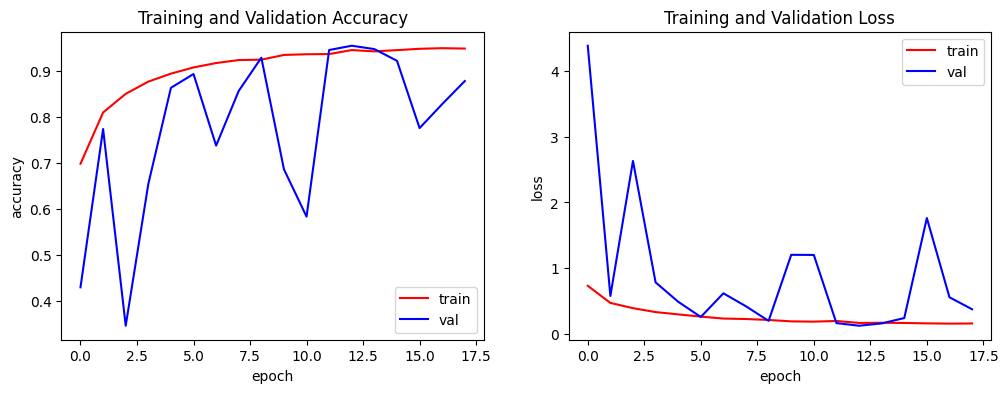

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'r', label='train')
plt.plot(epochs_range, val_acc, 'b', label='val')
plt.title('Training and Validation Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'r', label='train')
plt.plot(epochs_range, val_loss, 'b', label='val')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc='upper right')

plt.show()

In [16]:
eval_datagen = ImageDataGenerator(rescale=1./255)
train_eval_generator = eval_datagen.flow_from_dataframe(
    df_train, x_col='path', y_col='labels',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

train_loss, train_acc = model.evaluate(train_eval_generator)
test_loss, test_acc = model.evaluate(test_generator)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Found 12000 validated image filenames belonging to 3 classes.
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 149ms/step - accuracy: 0.9618 - loss: 0.1066
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.9567 - loss: 0.1316
Train accuracy: 0.9618333578109741
Test accuracy: 0.9566666483879089


47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step


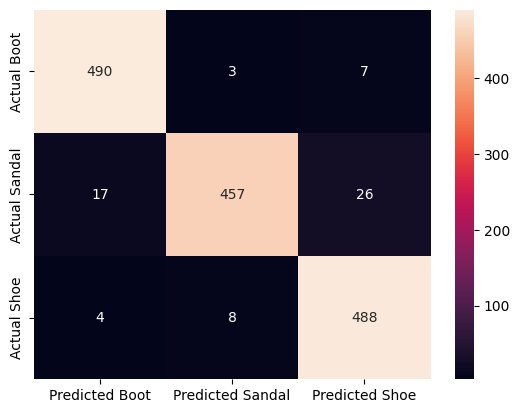

              precision    recall  f1-score   support

        Boot     0.9589    0.9800    0.9693       500
      Sandal     0.9765    0.9140    0.9442       500
        Shoe     0.9367    0.9760    0.9559       500

    accuracy                         0.9567      1500
   macro avg     0.9574    0.9567    0.9565      1500
weighted avg     0.9574    0.9567    0.9565      1500



In [17]:
from sklearn.metrics import classification_report, confusion_matrix

test_generator.reset()
pred = model.predict(test_generator)
y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

labels_name = list(test_generator.class_indices.keys())

cm = pd.DataFrame(
    confusion_matrix(y_true, y_pred),
    index=['Actual ' + c for c in labels_name],
    columns=['Predicted ' + c for c in labels_name]
)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

print(classification_report(y_true, y_pred, target_names=labels_name, digits=4))

In [18]:
model.export('saved_model')

INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  130365411904592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411907280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411906704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411908048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411904976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411906128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411908240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411909200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411909584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411910736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130365411909392: Te

In [ ]:
import pathlib

converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('model.tflite')
tflite_model_file.write_bytes(tflite_model)

labels_name = list(train_generator.class_indices.keys())
with open('label.txt', 'w') as f:
    for label in labels_name:
        f.write(label + '\n')

print("TFLite tersimpan:", tflite_model_file.stat().st_size, "bytes")
print("Label:", labels_name)

TFLite tersimpan: 5170940 bytes
Label: ['Boot', 'Sandal', 'Shoe']


W0000 00:00:1784791886.373179    1036 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784791886.373279    1036 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784791886.386310    1036 reader.cc:83] Reading SavedModel from: saved_model
I0000 00:00:1784791886.398496    1036 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784791886.398533    1036 reader.cc:147] Reading SavedModel debug info (if present) from: saved_model
I0000 00:00:1784791886.416630    1036 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1784791886.418604    1036 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784791886.710665    1036 loader.cc:220] Running initialization op on SavedModel bundle at path: saved_model
I0000 00:00:1784791886.729299    1036 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 343005 microseconds.


In [20]:
print(pathlib.Path('model.tflite').stat().st_size, "bytes")
print(open('label.txt').read())

5170940 bytes
Boot
Sandal
Shoe



/home/ken/tensflow/tfenv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


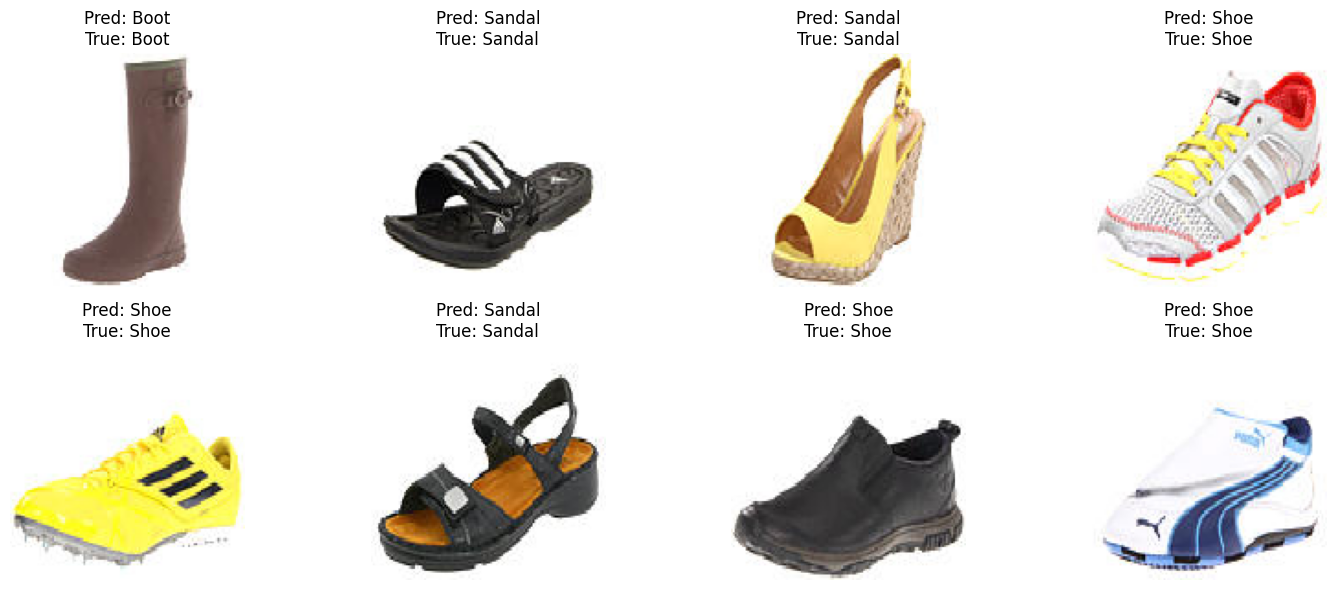

In [21]:
# Load TFLite model
interpreter = tf.lite.Interpreter(model_path='model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Ambil satu batch dari test generator
test_generator.reset()
images, labels = next(test_generator)

# Inference beberapa gambar
plt.figure(figsize=(15, 6))
for i in range(8):
    img = images[i:i+1]
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])

    pred_label = labels_name[np.argmax(output)]
    true_label = labels_name[np.argmax(labels[i])]

    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
model.save('model.h5')